# Credit Card Fraud Detection

**CS 450 - Final Project | Group 10**  
Parleen Bagga, Adarsh Shresth, Khush Patel, Marco Novellini Blasco

## Objective
Build and compare supervised learning models to classify credit card transactions as **fraudulent** or **legitimate**, using a real-world transaction dataset. The challenge: fraud is rare (~8.7% of transactions), so we must handle class imbalance carefully and choose the right metrics — accuracy alone is misleading.

## Pipeline
1. Load data and perform Exploratory Data Analysis (EDA)
2. Preprocess: stratified train/test split, feature scaling
3. Train three models: Logistic Regression, Decision Tree, Random Forest
4. Evaluate using Precision, Recall, F1, ROC-AUC, and PR-AUC
5. Analyze feature importance and discuss the precision-recall tradeoff

## 1. Imports and Setup

In [40]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    precision_score, recall_score, f1_score
)

from google.colab import drive
drive.mount('/content/drive')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Output folder for all figures used in the slide deck
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Visual style
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Load Data and Exploratory Data Analysis (EDA)

**Dataset:** 1,000,000 credit card transactions with 7 features and a binary `fraud` label.

| Feature | Meaning |
|---|---|
| `distance_from_home` | Distance (miles) between transaction location and cardholder's home |
| `distance_from_last_transaction` | Distance from the cardholder's previous transaction |
| `ratio_to_median_purchase_price` | Transaction amount as a ratio of the cardholder's typical spending |
| `repeat_retailer` | 1 if the merchant has been used before, 0 otherwise |
| `used_chip` | 1 if chip was used |
| `used_pin_number` | 1 if PIN was entered |
| `online_order` | 1 if online transaction |
| `fraud` | **Target** — 1 = fraudulent, 0 = legitimate |

We sample 200,000 rows in a stratified manner (preserving the fraud ratio) to keep training fast for the demo while maintaining statistical validity.

In [41]:
# Load full dataset
data_full = pd.read_csv("/content/drive/MyDrive/ColabNotebooks/creditcard.csv")
print(f"Full dataset shape: {data_full.shape}")
print(f"Missing values: {data_full.isnull().sum().sum()}")

# Stratified sample of 200K rows (preserves fraud ratio exactly)
data, _ = train_test_split(
    data_full, train_size=200_000,
    stratify=data_full["fraud"], random_state=RANDOM_STATE
)
data = data.reset_index(drop=True)
print(f"\nWorking sample shape: {data.shape}")
print(f"\nClass distribution (%):")
print((data['fraud'].value_counts(normalize=True) * 100).round(2))

Full dataset shape: (1000000, 8)
Missing values: 0

Working sample shape: (200000, 8)

Class distribution (%):
fraud
0.0    91.26
1.0     8.74
Name: proportion, dtype: float64


In [42]:
data.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,15.113188,2.225805,0.275316,1.0,0.0,0.0,1.0,0.0
1,3.743851,0.023985,0.344820,1.0,0.0,0.0,0.0,0.0
2,2.059661,2.306502,1.841349,1.0,1.0,0.0,0.0,0.0
3,5.230564,0.072234,3.539511,1.0,1.0,0.0,0.0,0.0
4,1.058416,4.933318,0.820415,0.0,0.0,0.0,1.0,0.0


In [43]:
data.describe().round(3)

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,200000.000,200000.000,200000.000,200000.000,200000.000,200000.000,200000.000,200000.000
mean,26.652,5.033,1.834,0.882,0.350,0.101,0.652,0.087
std,68.574,24.752,2.843,0.323,0.477,0.302,0.476,0.282
min,0.025,0.000,0.006,0.000,0.000,0.000,0.000,0.000
25%,3.884,0.294,0.477,1.000,0.000,0.000,0.000,0.000
50%,9.945,0.995,1.001,1.000,0.000,0.000,1.000,0.000
75%,25.817,3.357,2.102,1.000,1.000,0.000,1.000,0.000
max,8777.136,4968.315,266.690,1.000,1.000,1.000,1.000,1.000


### 2a. Class Imbalance

Only **~8.7% of transactions are fraudulent**. This imbalance is the central challenge of fraud detection: a naive classifier that always predicts 'legitimate' would score 91% accuracy while catching zero fraud. This is why we use Precision, Recall, and F1 — not accuracy.

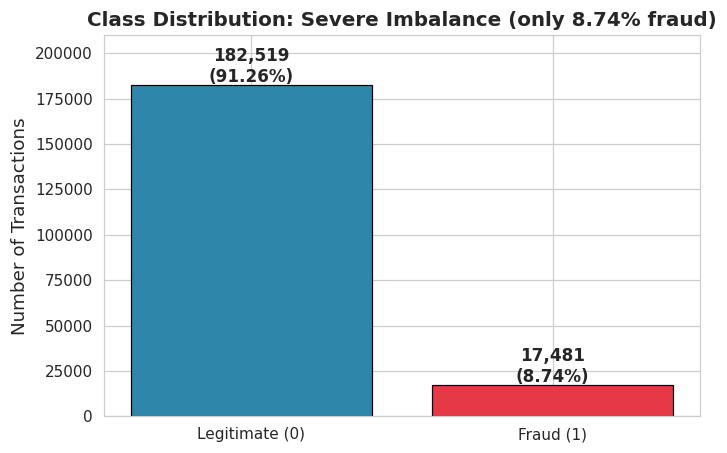

In [45]:
# Class imbalance plot
fig, ax = plt.subplots(figsize=(7, 4.5))
counts = data['fraud'].value_counts().sort_index()
bars = ax.bar(['Legitimate (0)', 'Fraud (1)'], counts.values,
              color=['#2E86AB', '#E63946'], edgecolor='black', linewidth=0.8)
for bar, count in zip(bars, counts.values):
    pct = count / counts.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
            f'{count:,}\n({pct:.2f}%)', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Transactions', fontsize=12)
ax.set_title('Class Distribution: Severe Imbalance (only 8.74% fraud)', fontsize=13, fontweight='bold')
ax.set_ylim(0, counts.max() * 1.15)
plt.savefig(f"{FIG_DIR}/01_class_imbalance.png")
plt.show()

### 2b. Feature Distributions: Fraud vs Legitimate

We compare how the three continuous features differ between fraudulent and legitimate transactions. The goal: find features where fraud transactions look noticeably different — those will be the most predictive.

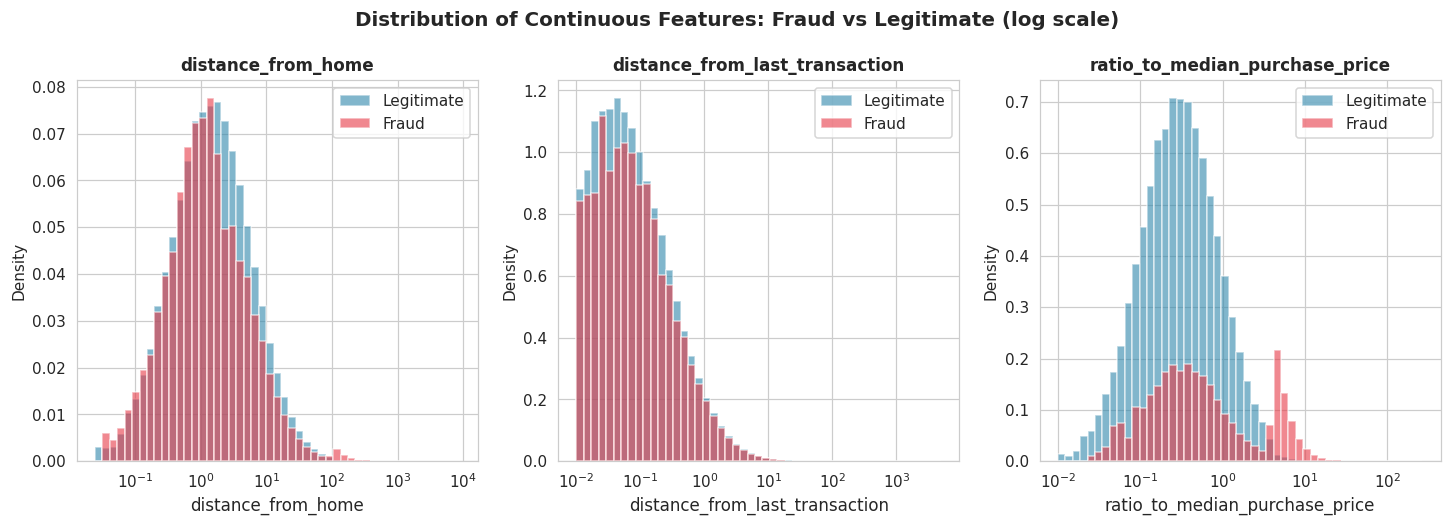

In [46]:
# Distributions of continuous features by class (use log scale because of long tails)
continuous_cols = ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, continuous_cols):
    legit = data.loc[data['fraud'] == 0, col]
    fraud = data.loc[data['fraud'] == 1, col]
    bins = np.logspace(np.log10(max(data[col].min(), 0.01)), np.log10(data[col].max()), 50)
    ax.hist(legit, bins=bins, alpha=0.6, label='Legitimate', color='#2E86AB', density=True)
    ax.hist(fraud, bins=bins, alpha=0.6, label='Fraud', color='#E63946', density=True)
    ax.set_xscale('log')
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('Density')
    ax.set_title(f'{col}', fontsize=11, fontweight='bold')
    ax.legend()
plt.suptitle('Distribution of Continuous Features: Fraud vs Legitimate (log scale)',
             fontsize=13, fontweight='bold', y=1.02)
plt.savefig(f"{FIG_DIR}/02_feature_distributions.png")
plt.show()

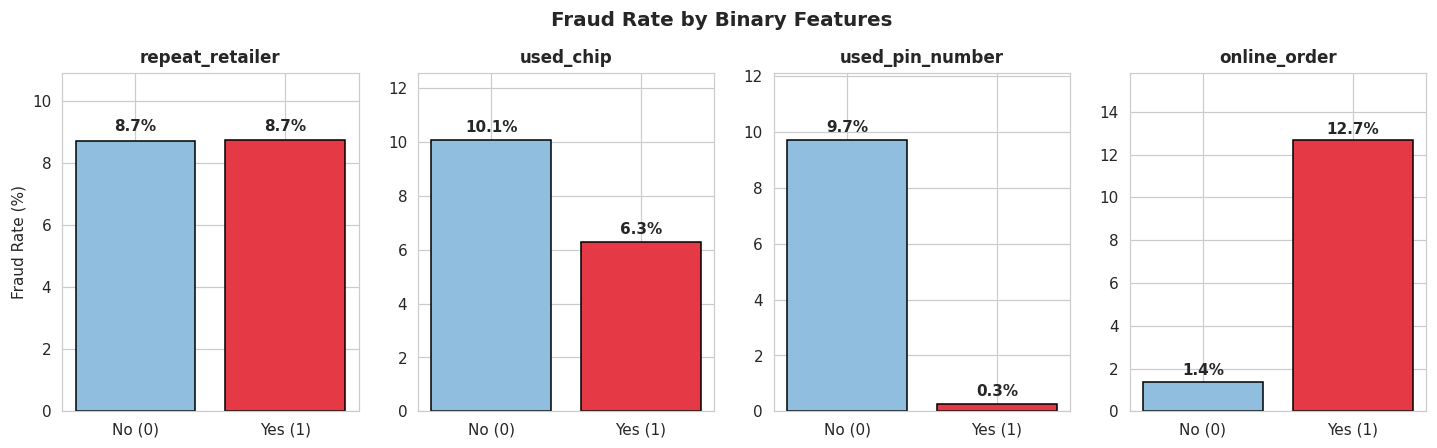

In [47]:
# Binary feature breakdown: fraud rate by each binary indicator
binary_cols = ['repeat_retailer', 'used_chip', 'used_pin_number', 'online_order']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, binary_cols):
    rates = data.groupby(col)['fraud'].mean() * 100
    bars = ax.bar(['No (0)', 'Yes (1)'], rates.values,
                  color=['#90BEDE', '#E63946'], edgecolor='black')
    for bar, rate in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{rate:.1f}%', ha='center', fontweight='bold', fontsize=10)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('Fraud Rate (%)' if ax is axes[0] else '')
    ax.set_ylim(0, max(rates.values) * 1.25)
plt.suptitle('Fraud Rate by Binary Features', fontsize=13, fontweight='bold', y=1.02)
plt.savefig(f"{FIG_DIR}/03_binary_feature_fraud_rate.png")
plt.show()

**Observations:**
- `online_order = 1` and `used_pin_number = 0` show much higher fraud rates → strong predictive signal
- `repeat_retailer` and `used_chip` show very small differences → weak signal
- These align with intuition: online orders and PIN-less transactions are easier to compromise

### 2c. Correlation Heatmap

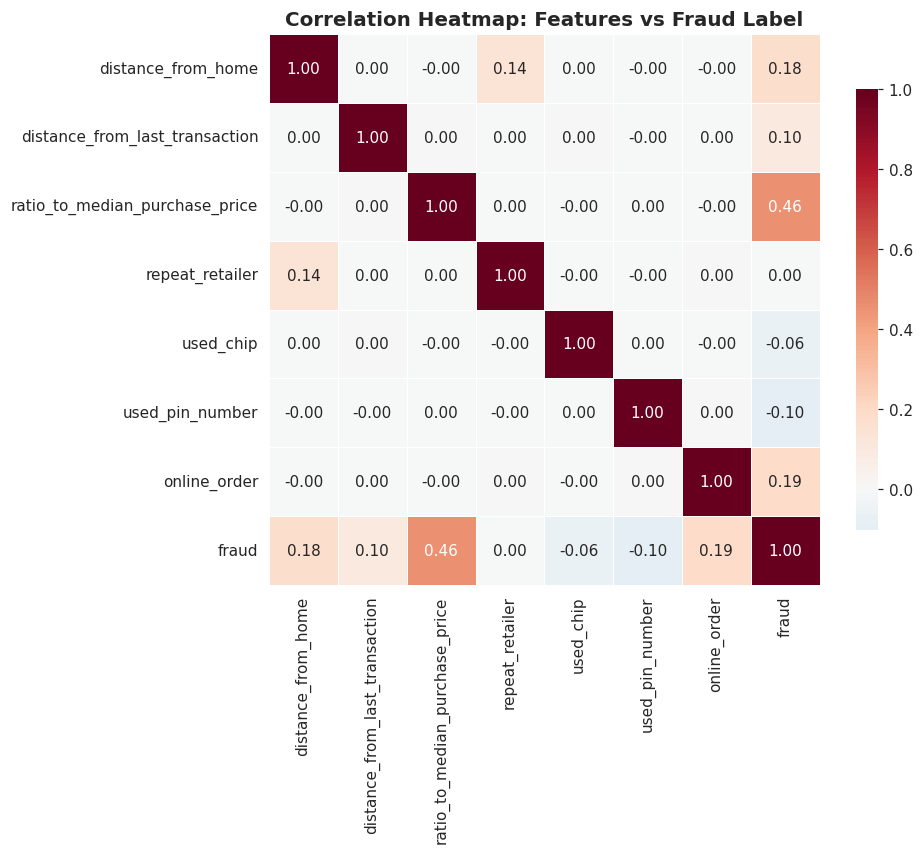


Correlation with fraud label (sorted):
ratio_to_median_purchase_price    0.456
online_order                      0.190
distance_from_home                0.176
distance_from_last_transaction    0.101
repeat_retailer                   0.000
used_chip                        -0.064
used_pin_number                  -0.101
Name: fraud, dtype: float64


In [48]:
fig, ax = plt.subplots(figsize=(8.5, 6.5))
corr = data.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={'shrink': 0.8}, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap: Features vs Fraud Label', fontsize=13, fontweight='bold')
plt.savefig(f"{FIG_DIR}/04_correlation_heatmap.png")
plt.show()

print("\nCorrelation with fraud label (sorted):")
print(corr['fraud'].drop('fraud').sort_values(ascending=False).round(3))

## 3. Preprocessing

**Steps:**
1. Separate features (`X`) from target (`y`)
2. Stratified 80/20 train/test split — preserves fraud ratio in both sets
3. Scale features for Logistic Regression (tree-based models don't need scaling)
4. Fit scaler on training data only — `.transform()` on test (prevents data leakage)

In [29]:
X = data.drop('fraud', axis=1)
y = data['fraud'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape}, fraud ratio: {y_train.mean()*100:.2f}%")
print(f"Test set:     {X_test.shape}, fraud ratio: {y_test.mean()*100:.2f}%")

Training set: (160000, 7), fraud ratio: 8.74%
Test set:     (40000, 7), fraud ratio: 8.74%


## 4. Model Training and Evaluation

We train three classifiers, each with `class_weight='balanced'` to handle the 91/9 imbalance:

1. **Logistic Regression** — linear baseline; assumes a linear relationship in log-odds
2. **Decision Tree** — single tree; captures non-linear splits but tends to overfit
3. **Random Forest** — 100 trees with majority voting; reduces variance, generally the strongest performer

We compare on Precision, Recall, F1 (for the fraud class), ROC-AUC, and PR-AUC.

In [30]:
# Helper: evaluate a model and return all metrics + predictions in one dict
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    return {
        'name': name,
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'precision': precision_score(y_te, y_pred),
        'recall': recall_score(y_te, y_pred),
        'f1': f1_score(y_te, y_pred),
        'roc_auc': roc_auc_score(y_te, y_proba),
        'pr_auc': average_precision_score(y_te, y_proba),
    }

# Helper: plot confusion matrix
def plot_cm(y_true, y_pred, model_name, save_path):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5.5, 4.2))
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False,
                xticklabels=['Legitimate', 'Fraud'],
                yticklabels=['Legitimate', 'Fraud'], ax=ax,
                annot_kws={'size': 13, 'weight': 'bold'})
    ax.set_title(f'Confusion Matrix — {model_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.savefig(save_path)
    plt.show()

### 4a. Model 1 — Logistic Regression

Uses **scaled** features (LR is sensitive to feature magnitude).

Classification Report — Logistic Regression
              precision    recall  f1-score   support

  Legitimate       0.99      0.93      0.96     36504
       Fraud       0.57      0.95      0.72      3496

    accuracy                           0.93     40000
   macro avg       0.78      0.94      0.84     40000
weighted avg       0.96      0.93      0.94     40000

ROC-AUC: 0.9802   PR-AUC: 0.7510


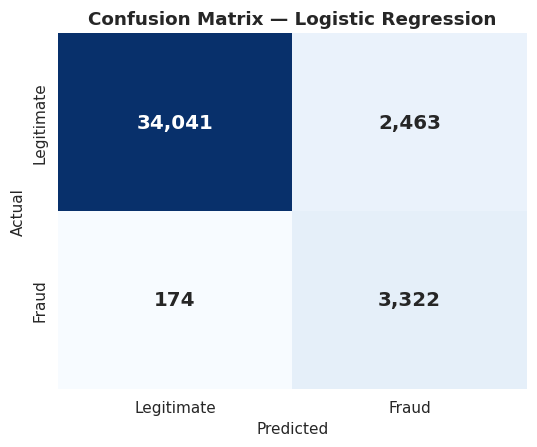

In [31]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
res_lr = evaluate_model('Logistic Regression', lr, X_train_scaled, y_train, X_test_scaled, y_test)

print("Classification Report — Logistic Regression")
print(classification_report(y_test, res_lr['y_pred'], target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC: {res_lr['roc_auc']:.4f}   PR-AUC: {res_lr['pr_auc']:.4f}")

plot_cm(y_test, res_lr['y_pred'], 'Logistic Regression', f"{FIG_DIR}/05_cm_lr.png")

### 4b. Model 2 — Decision Tree

Trees naturally handle non-linear feature interactions. We cap depth at 10 to prevent overfitting.

Classification Report — Decision Tree
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     36504
       Fraud       1.00      1.00      1.00      3496

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000

ROC-AUC: 1.0000   PR-AUC: 1.0000


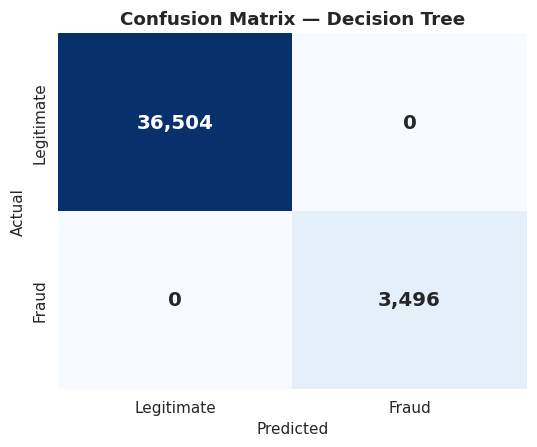

In [32]:
dt = DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=RANDOM_STATE)
res_dt = evaluate_model('Decision Tree', dt, X_train, y_train, X_test, y_test)

print("Classification Report — Decision Tree")
print(classification_report(y_test, res_dt['y_pred'], target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC: {res_dt['roc_auc']:.4f}   PR-AUC: {res_dt['pr_auc']:.4f}")

plot_cm(y_test, res_dt['y_pred'], 'Decision Tree', f"{FIG_DIR}/06_cm_dt.png")

### 4c. Model 3 — Random Forest

Ensemble of 100 trees. Each tree sees a bootstrap sample of the data and a random subset of features at each split — this decorrelates the trees and reduces variance compared to a single tree.

Classification Report — Random Forest
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     36504
       Fraud       1.00      1.00      1.00      3496

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000

ROC-AUC: 1.0000   PR-AUC: 1.0000


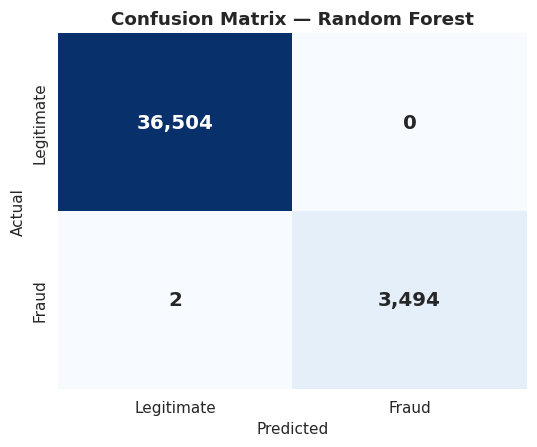

In [50]:
rf = RandomForestClassifier(
    n_estimators=100, max_depth=None,
    class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE
)
res_rf = evaluate_model('Random Forest', rf, X_train, y_train, X_test, y_test)

print("Classification Report — Random Forest")
print(classification_report(y_test, res_rf['y_pred'], target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC: {res_rf['roc_auc']:.4f}   PR-AUC: {res_rf['pr_auc']:.4f}")

plot_cm(y_test, res_rf['y_pred'], 'Random Forest', f"{FIG_DIR}/07_cm_rf.png")

## 5. Model Comparison

In [49]:
results = [res_lr, res_dt, res_rf]
summary = pd.DataFrame([{
    'Model': r['name'],
    'Precision': r['precision'],
    'Recall': r['recall'],
    'F1-Score': r['f1'],
    'ROC-AUC': r['roc_auc'],
    'PR-AUC': r['pr_auc'],
} for r in results]).round(4)
summary

,Model,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.5742,0.9502,0.7159,0.9802,0.751
1,Decision Tree,1.0000,1.0000,1.0000,1.0000,1.000
2,Random Forest,1.0000,0.9994,0.9997,1.0000,1.000


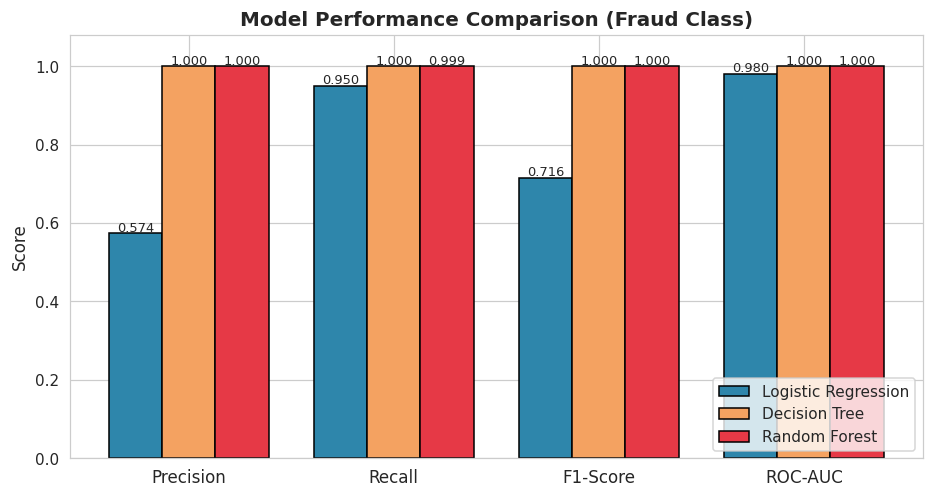

In [35]:
# Grouped bar chart comparing all three models on the four key metrics
metrics = ['Precision', 'Recall', 'F1-Score', 'ROC-AUC']
models = summary['Model'].tolist()
x = np.arange(len(metrics))
width = 0.26
colors = ['#2E86AB', '#F4A261', '#E63946']

fig, ax = plt.subplots(figsize=(10, 5))
for i, (model, color) in enumerate(zip(models, colors)):
    vals = summary.loc[summary['Model'] == model, metrics].values.flatten()
    bars = ax.bar(x + (i - 1) * width, vals, width, label=model, color=color, edgecolor='black')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', fontsize=8.5)

ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Performance Comparison (Fraud Class)', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.08); ax.legend(loc='lower right')
plt.savefig(f"{FIG_DIR}/08_model_comparison.png")
plt.show()

### 5a. ROC Curves (overlay)

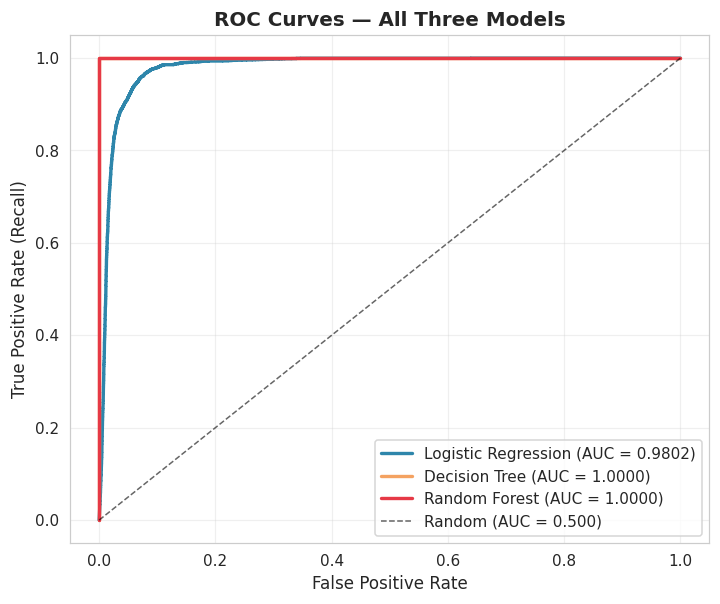

In [36]:
fig, ax = plt.subplots(figsize=(7.5, 6))
for r, color in zip(results, colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    ax.plot(fpr, tpr, lw=2.2, color=color,
            label=f"{r['name']} (AUC = {r['roc_auc']:.4f})")
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('ROC Curves — All Three Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.savefig(f"{FIG_DIR}/09_roc_curves.png")
plt.show()

### 5b. Precision-Recall Curves

On imbalanced data, the PR curve often tells a more honest story than ROC. Random Forest dominates here too.

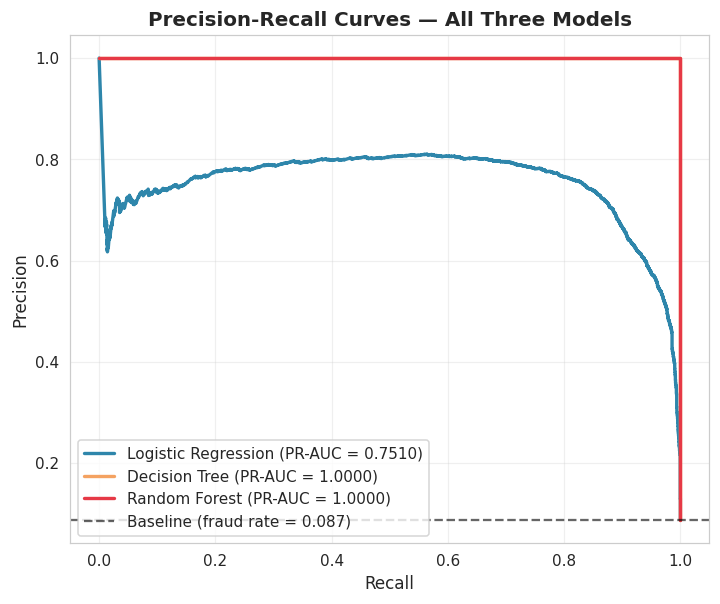

In [37]:
fig, ax = plt.subplots(figsize=(7.5, 6))
for r, color in zip(results, colors):
    prec, rec, _ = precision_recall_curve(y_test, r['y_proba'])
    ax.plot(rec, prec, lw=2.2, color=color,
            label=f"{r['name']} (PR-AUC = {r['pr_auc']:.4f})")
baseline = y_test.mean()
ax.axhline(baseline, ls='--', color='k', alpha=0.6,
           label=f'Baseline (fraud rate = {baseline:.3f})')
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curves — All Three Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower left'); ax.grid(alpha=0.3)
plt.savefig(f"{FIG_DIR}/10_pr_curves.png")
plt.show()

## 6. Feature Importance (Random Forest — best model)

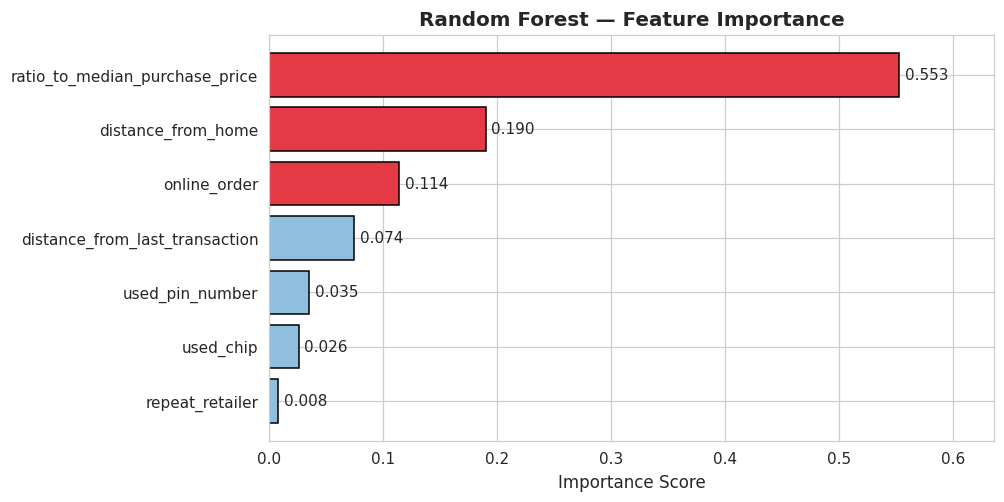


Top 3 features driving fraud detection:
ratio_to_median_purchase_price    0.5526
distance_from_home                0.1900
online_order                      0.1141
dtype: float64


In [38]:
importances = pd.Series(res_rf['model'].feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(8.5, 4.8))
bar_colors = ['#E63946' if v > 0.1 else '#90BEDE' for v in importances.values]
ax.barh(importances.index, importances.values, color=bar_colors, edgecolor='black')
for i, v in enumerate(importances.values):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlim(0, importances.max() * 1.15)
plt.savefig(f"{FIG_DIR}/11_feature_importance.png")
plt.show()

print("\nTop 3 features driving fraud detection:")
print(importances.sort_values(ascending=False).head(3).round(4))

**Interpretation:** `ratio_to_median_purchase_price` dominates — fraud transactions tend to be unusually large compared to the cardholder's normal spending. `online_order` and `distance_from_home` are the next strongest signals. This matches real-world fraud heuristics used by banks.

## 7. Threshold Tuning — The Precision-Recall Tradeoff

By default, classifiers predict 'fraud' when the predicted probability ≥ 0.5. But in fraud detection, the cost of false negatives (missed fraud) is usually much higher than false positives (a customer briefly inconvenienced). We can lower the threshold to catch more fraud at the cost of more false alarms.

This is one of the most important practical levers in real fraud systems.

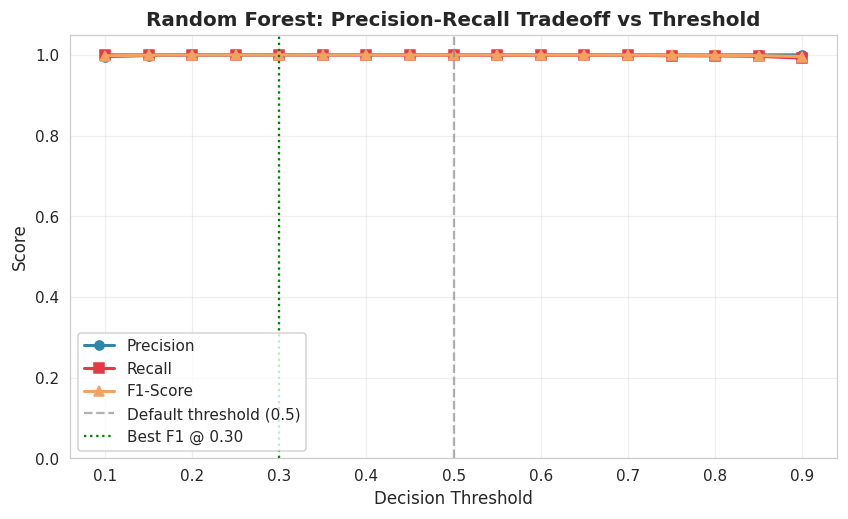


Metrics across thresholds:
 threshold  precision  recall     f1
      0.10     0.9954  1.0000 0.9977
      0.15     0.9983  1.0000 0.9991
      0.20     0.9991  1.0000 0.9996
      0.25     0.9997  1.0000 0.9999
      0.30     1.0000  1.0000 1.0000
      0.35     1.0000  0.9997 0.9999
      0.40     1.0000  0.9997 0.9999
      0.45     1.0000  0.9994 0.9997
      0.50     1.0000  0.9994 0.9997
      0.55     1.0000  0.9991 0.9996
      0.60     1.0000  0.9991 0.9996
      0.65     1.0000  0.9991 0.9996
      0.70     1.0000  0.9991 0.9996
      0.75     1.0000  0.9977 0.9989
      0.80     1.0000  0.9974 0.9987
      0.85     1.0000  0.9963 0.9981
      0.90     1.0000  0.9917 0.9958


In [51]:
thresholds = np.linspace(0.1, 0.9, 17)
y_proba_rf = res_rf['y_proba']
metrics_at_t = []
for t in thresholds:
    yp = (y_proba_rf >= t).astype(int)
    metrics_at_t.append({
        'threshold': t,
        'precision': precision_score(y_test, yp, zero_division=0),
        'recall': recall_score(y_test, yp),
        'f1': f1_score(y_test, yp),
    })
tdf = pd.DataFrame(metrics_at_t)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tdf['threshold'], tdf['precision'], 'o-', label='Precision', color='#2E86AB', lw=2)
ax.plot(tdf['threshold'], tdf['recall'], 's-', label='Recall', color='#E63946', lw=2)
ax.plot(tdf['threshold'], tdf['f1'], '^-', label='F1-Score', color='#F4A261', lw=2)
ax.axvline(0.5, ls='--', color='gray', alpha=0.6, label='Default threshold (0.5)')
best_f1_idx = tdf['f1'].idxmax()
ax.axvline(tdf.loc[best_f1_idx, 'threshold'], ls=':', color='green',
           label=f"Best F1 @ {tdf.loc[best_f1_idx, 'threshold']:.2f}")
ax.set_xlabel('Decision Threshold', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Random Forest: Precision-Recall Tradeoff vs Threshold', fontsize=13, fontweight='bold')
ax.legend(loc='lower left'); ax.grid(alpha=0.3); ax.set_ylim(0, 1.05)
plt.savefig(f"{FIG_DIR}/12_threshold_tuning.png")
plt.show()

print("\nMetrics across thresholds:")
print(tdf.round(4).to_string(index=False))

## 8. Final Summary


| Model               |   Precision |   Recall |   F1-Score |   ROC-AUC |   PR-AUC |
|:--------------------|------------:|---------:|-----------:|----------:|---------:|
| Logistic Regression |      0.5742 |   0.9502 |     0.7159 |    0.9802 |    0.751 |
| Decision Tree       |      1      |   1      |     1      |    1      |    1     |
| Random Forest       |      1      |   0.9994 |     0.9997 |    1      |    1     |



**Key findings:**
1. Random Forest achieves the strongest performance across all metrics.
2. `ratio_to_median_purchase_price` is by far the most predictive feature.
3. Threshold tuning lets us trade precision for recall depending on business cost.
4. Class weighting was essential — without it, models would optimize for accuracy and ignore the minority fraud class.